In [3]:
!pip install wordcloud

In [4]:
#Step 1: Import Required Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

In [6]:
#Step 2: Load the Dataset

# Load the dataset
data = pd.read_csv('netflix_titles.csv')

# Display the first few rows of the dataset
print(data.head())

  show_id     type                             title         director  \
0      s1    Movie              Dick Johnson Is Dead  Kirsten Johnson   
1      s3  TV Show                         Ganglands  Julien Leclercq   
2      s6  TV Show                     Midnight Mass    Mike Flanagan   
3     s14    Movie  Confessions of an Invisible Girl    Bruno Garotti   
4      s8    Movie                           Sankofa     Haile Gerima   

         country date_added  release_year rating  duration  \
0  United States  9/25/2021          2020  PG-13    90 min   
1         France  9/24/2021          2021  TV-MA  1 Season   
2  United States  9/24/2021          2021  TV-MA  1 Season   
3         Brazil  9/22/2021          2021  TV-PG    91 min   
4  United States  9/24/2021          1993  TV-MA   125 min   

                                           listed_in  
0                                      Documentaries  
1  Crime TV Shows, International TV Shows, TV Act...  
2                 TV Dr

In [8]:
#Step 3: Data Cleaning

# Check for missing values
print(data.isnull().sum())

# Drop duplicates if any
data.drop_duplicates(inplace=True)

# Drop rows with missing critical information
data.dropna(subset=['director', 'title', 'country'],
inplace=True)

# Convert 'date_added' to datetime
data['date_added'] = pd.to_datetime(data['date_added'])

# Show data types to confirm changes
print(data.dtypes)

show_id         0
type            0
title           0
director        0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
dtype: int64
show_id                 object
type                    object
title                   object
director                object
country                 object
date_added      datetime64[ns]
release_year             int64
rating                  object
duration                object
listed_in               object
dtype: object


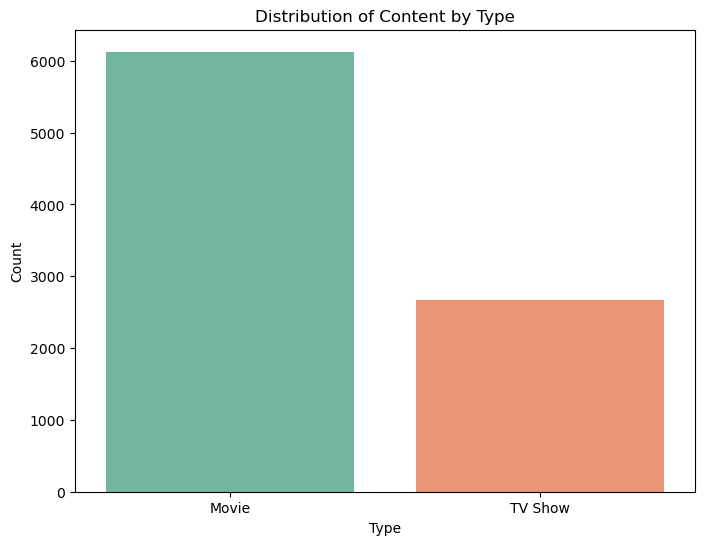

In [10]:
#Step 4: Exploratory Data Analysis (EDA)

#1. Content Type Distribution (Movies vs. TV Shows)
# Count the number of Movies and TV Shows
type_counts = data['type'].value_counts()

# Plot the distribution
plt.figure(figsize=(8, 6))
sns.barplot(x=type_counts.index, y=type_counts.values,
palette='Set2')
plt.title('Distribution of Content by Type')
plt.xlabel('Type')
plt.ylabel('Count')
plt.show()

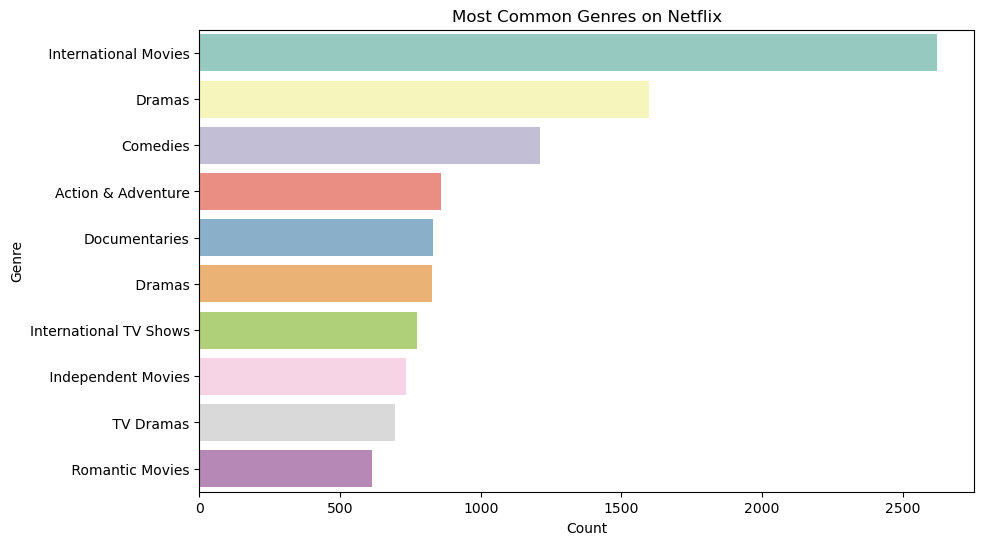

In [11]:
#2. Most Common Genres

# Split the 'listed_in' column and count genres
data['genres'] = data['listed_in'].apply(lambda x: x.split(','))
all_genres = sum(data['genres'], [])
genre_counts = pd.Series(all_genres).value_counts().head(10)

# Plot the most common genres
plt.figure(figsize=(10, 6))
sns.barplot(x=genre_counts.values, y=genre_counts.index,palette='Set3')
plt.title('Most Common Genres on Netflix')
plt.xlabel('Count')
plt.ylabel('Genre')
plt.show()

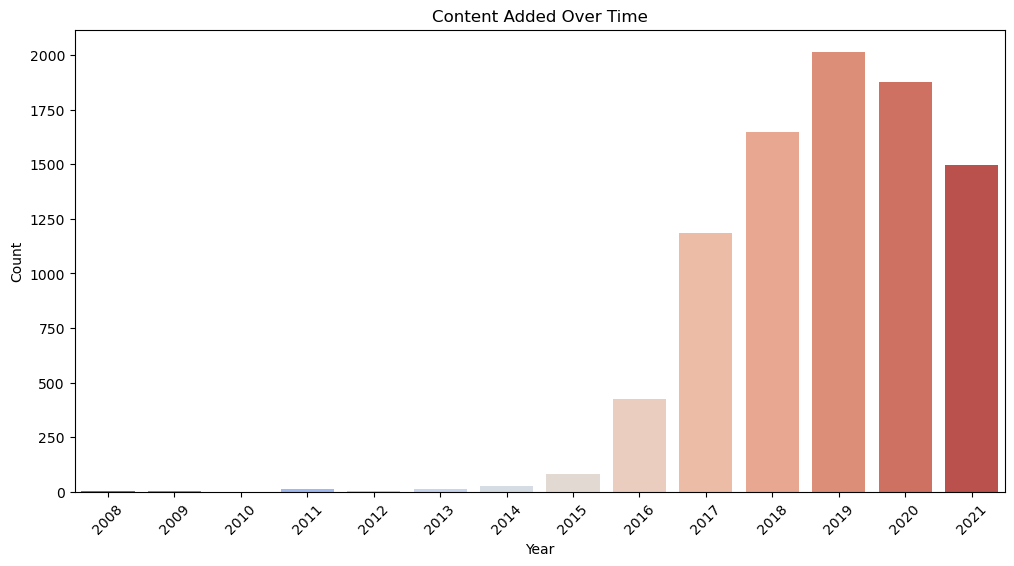

In [12]:
#3. Content Added Over Time
# Extract year and month from 'date_added'
data['year_added'] = data['date_added'].dt.year
data['month_added'] = data['date_added'].dt.month

# Plot content added over the years
plt.figure(figsize=(12, 6))
sns.countplot(x='year_added', data=data, palette='coolwarm')
plt.title('Content Added Over Time')
plt.xlabel('Year')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

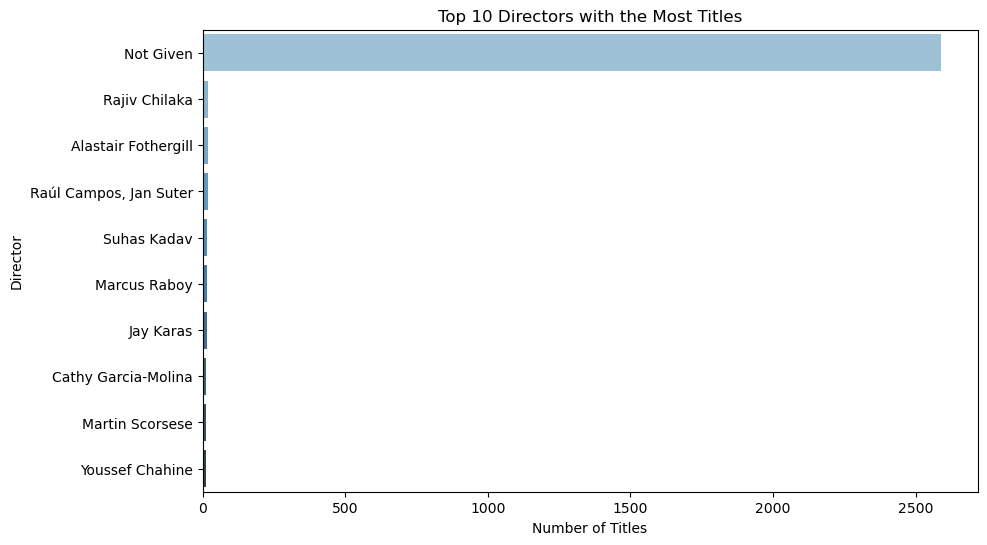

In [14]:
#4. Top 10 Directors with the Most Titles

# Count titles by director
top_directors = data['director'].value_counts().head(10)

# Plot top directors
plt.figure(figsize=(10, 6))
sns.barplot(x=top_directors.values, y=top_directors.index,palette='Blues_d')
plt.title('Top 10 Directors with the Most Titles')
plt.xlabel('Number of Titles')
plt.ylabel('Director')
plt.show()

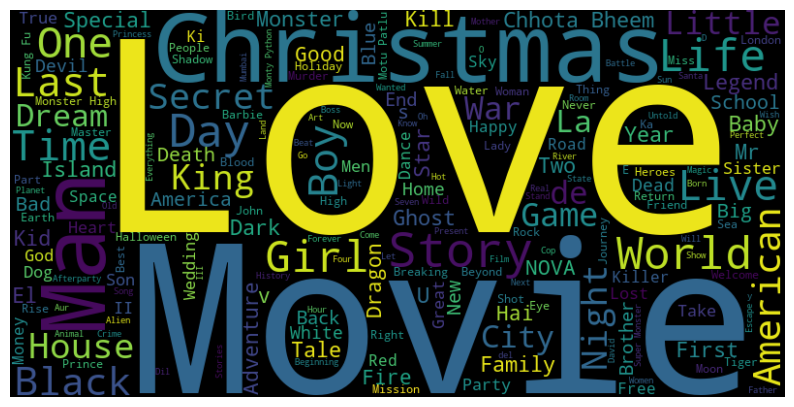

In [15]:
#5. Word Cloud of Movie Titles
# Generate word cloud
movie_titles = data[data['type'] == 'Movie']['title']
wordcloud = WordCloud(width=800, height=400,
background_color='black').generate(' '.join(movie_titles))

# Plot word cloud
plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

In [18]:
import pandas as pd

# Load the dataset
file_path = r"C:\Users\Haneefa Ghazi\netflix_titles.csv"
data = pd.read_csv(file_path)

# Display unique duration values for debugging
print("Unique duration values:", data['duration'].dropna().unique())

# Feature Engineering

# 1. Count the number of genres per movie (assuming 'listed_in' contains genres)
if 'listed_in' in data.columns:
    data['Genre_Count'] = data['listed_in'].astype(str).apply(lambda x: len(x.split(',')))

# 2. Extract duration in minutes (fixing errors in formatting)
if 'duration' in data.columns:
    def extract_minutes(duration):
        if pd.isna(duration):
            return None  # Handle missing values
        
        duration = str(duration).lower().strip()
        duration = duration.replace(" min", "").replace("mins", "").replace("minutes", "").strip()
        
        if duration.isdigit():  # If it's a pure number, convert to int
            return int(duration)
        
        elif "h" in duration:  # Handle cases like "2h 30m"
            parts = duration.replace("h", "").replace("m", "").split()
            try:
                if len(parts) == 2:
                    return int(parts[0]) * 60 + int(parts[1])
                elif len(parts) == 1:
                    return int(parts[0]) * 60  # If only hours exist
            except ValueError:
                return None  # Handle unexpected formats

        return None  # Handle completely invalid formats
    
    data['Duration_Minutes'] = data['duration'].apply(extract_minutes)

# Display the first few rows with new features
print(data[['listed_in', 'Genre_Count', 'duration', 'Duration_Minutes']].head())

# Save the updated dataset
output_path = r"C:\Users\Haneefa Ghazi\netflix_titles_updated.csv"
data.to_csv(output_path, index=False)
print(f"Updated dataset saved to {output_path}")


Unique duration values: ['90 min' '1 Season' '91 min' '125 min' '9 Seasons' '104 min' '87 min'
 '127 min' '76 min' '71 min' '131 min' '39 min' '36 min' '34 min' '35 min'
 '46 min' '67 min' '65 min' '61 min' '166 min' '103 min' '97 min'
 '106 min' '2 Seasons' '4 Seasons' '147 min' '94 min' '161 min' '111 min'
 '110 min' '105 min' '96 min' '124 min' '116 min' '98 min' '115 min'
 '122 min' '55 min' '99 min' '88 min' '100 min' '6 Seasons' '3 Seasons'
 '23 min' '102 min' '93 min' '95 min' '85 min' '83 min' '182 min'
 '5 Seasons' '92 min' '84 min' '48 min' '145 min' '119 min' '80 min'
 '128 min' '143 min' '273 min' '117 min' '114 min' '118 min' '108 min'
 '37 min' '121 min' '63 min' '142 min' '113 min' '154 min' '120 min'
 '82 min' '109 min' '101 min' '86 min' '77 min' '229 min' '15 min'
 '89 min' '156 min' '112 min' '107 min' '129 min' '44 min' '68 min'
 '135 min' '136 min' '165 min' '150 min' '133 min' '47 min' '70 min'
 '56 min' '58 min' '78 min' '140 min' '64 min' '59 min' '60 min' '69 m